In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import find_peaks


CSV_INPUT = Path(r"C:\Users\david\Documents\TFG\metrics\train.csv") 
CSV_FOLDER = Path(r"C:\Users\david\Documents\TFG\datos_csv")
all_files = sorted(list(CSV_FOLDER.glob('*.csv')))

In [39]:
df = pd.read_csv(CSV_INPUT)


In [40]:
def calculate_angle(a, b, c):
    """
    Calcula el ángulo en grados entre 3 puntos (A-B-C), siendo B el vértice.
    Usa el producto escalar de vectores.
    """
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba = a - b
    bc = c - b
    
    denom = np.linalg.norm(ba) * np.linalg.norm(bc)
    if denom == 0: return 0.0
    
    cosine = np.dot(ba, bc) / denom
    angle = np.arccos(np.clip(cosine, -1.0, 1.0))
    return np.degrees(angle)

def calculate_distance(p1, p2):
    """Calcula la distancia euclidiana entre dos puntos (x, y)."""
    return np.linalg.norm(np.array(p1) - np.array(p2))

In [41]:
def detectar_fases_saque(angulos, max_dist_frames=200):
    """
    Identifica los hitos temporales del saque basándose en la topología de la señal.
    
    Args:
        angulos (list): Lista de ángulos de flexión de rodilla.
        max_dist_frames (int): Distancia máxima permitida entre carga y extensión.
        
    Returns:
        tuple: (start_frame, min_frame, max_frame, target_frame)
               Inicio (Morado), Carga (Rojo), Extensión (Verde), Target (Amarillo)
    """
    data = np.array(angulos)
    
    # 1. Búsqueda de Candidatos (Picos y Valles)
    picos_idx, _ = find_peaks(data, height=150, distance=20)   # Extensión
    valles_idx, _ = find_peaks(-data, height=-165, distance=20) # Flexión
    
    # 2. Selección de la Mejor Pareja (Mayor Rango Ascendente)
    best_score, best_min, best_max = -1, -1, -1
    
    for valle in valles_idx:
        for pico in picos_idx:
            # Lógica temporal: Valle debe ir antes que Pico
            if valle < pico:
                if (pico - valle) < max_dist_frames:
                    recorrido = data[pico] - data[valle]
                    # Maximizamos la subida (ROM)
                    if recorrido > best_score:
                        best_score = recorrido
                        best_min = valle
                        best_max = pico
    
    # Fallback de seguridad
    if best_min == -1: 
        best_min, best_max = np.argmin(data), np.argmax(data)
        
    # 3. Refinamiento del Mínimo (Lupa local)
    ventana = 10
    ini, end = max(0, best_min - ventana), min(len(data), best_min + ventana)
    best_min = ini + np.argmin(data[ini:end])
    
    # 4. Cálculo del Target Frame (Factor 0.325)
    # Punto de máxima inercia antes del despegue
    target = int(best_min + (best_max - best_min) * 0.325)
    
    # 5. Búsqueda del Inicio (Punto Morado)
    # Miramos hacia atrás buscando la posición erguida previa
    s_search = max(0, best_min - 150)
    pre_data = data[s_search:best_min]
    start = s_search + np.argmax(pre_data) if len(pre_data) > 0 else 0
    
    return start, best_min, best_max, target

**ESTUDIAMOS NULL**

In [42]:
nulos = df.isnull().sum()
total_nulos = nulos.sum()
if total_nulos > 0:
    print(f"⚠️ ALERTA: Se encontraron {total_nulos} valores vacíos (NaN):")
    print(nulos[nulos > 0])
    
    # Identificar qué vídeos son los problemáticos
    filas_malas = df[df.isnull().any(axis=1)]
    print("\n   -> Vídeos con errores (para revisar):")
    print(filas_malas['Video_ID'].tolist())
else:
    print("✅ No hay valores nulos (NaN). El dataset está limpio.")

⚠️ ALERTA: Se encontraron 15 valores vacíos (NaN):
Ankle_Drag    7
Knee_Start    7
Knee_Min      1
dtype: int64

   -> Vídeos con errores (para revisar):
['flat_pinpoint_67_landmarks.csv', 'flat_platform_150_landmarks.csv', 'flat_platform_98_landmarks.csv', 'kick_platform_19_landmarks.csv', 'kick_platform_22_landmarks.csv', 'kick_platform_37_landmarks.csv', 'slice_platform_128_landmarks.csv']


*Analizamos con gráficos las filas malas*

In [43]:
ids_malos = filas_malas['Video_ID'].tolist()
archivos_malos = []

for video_id in ids_malos:
    encontrado = next((f for f in all_files if f.name ==video_id), None)

    if encontrado:
        archivos_malos.append(encontrado)
        
print(len(archivos_malos))
archivos_malos

7


[WindowsPath('C:/Users/david/Documents/TFG/datos_csv/flat_pinpoint_67_landmarks.csv'),
 WindowsPath('C:/Users/david/Documents/TFG/datos_csv/flat_platform_150_landmarks.csv'),
 WindowsPath('C:/Users/david/Documents/TFG/datos_csv/flat_platform_98_landmarks.csv'),
 WindowsPath('C:/Users/david/Documents/TFG/datos_csv/kick_platform_19_landmarks.csv'),
 WindowsPath('C:/Users/david/Documents/TFG/datos_csv/kick_platform_22_landmarks.csv'),
 WindowsPath('C:/Users/david/Documents/TFG/datos_csv/kick_platform_37_landmarks.csv'),
 WindowsPath('C:/Users/david/Documents/TFG/datos_csv/slice_platform_128_landmarks.csv')]

⚠️ Error en flat_pinpoint_67_landmarks.csv: cannot convert float NaN to integer


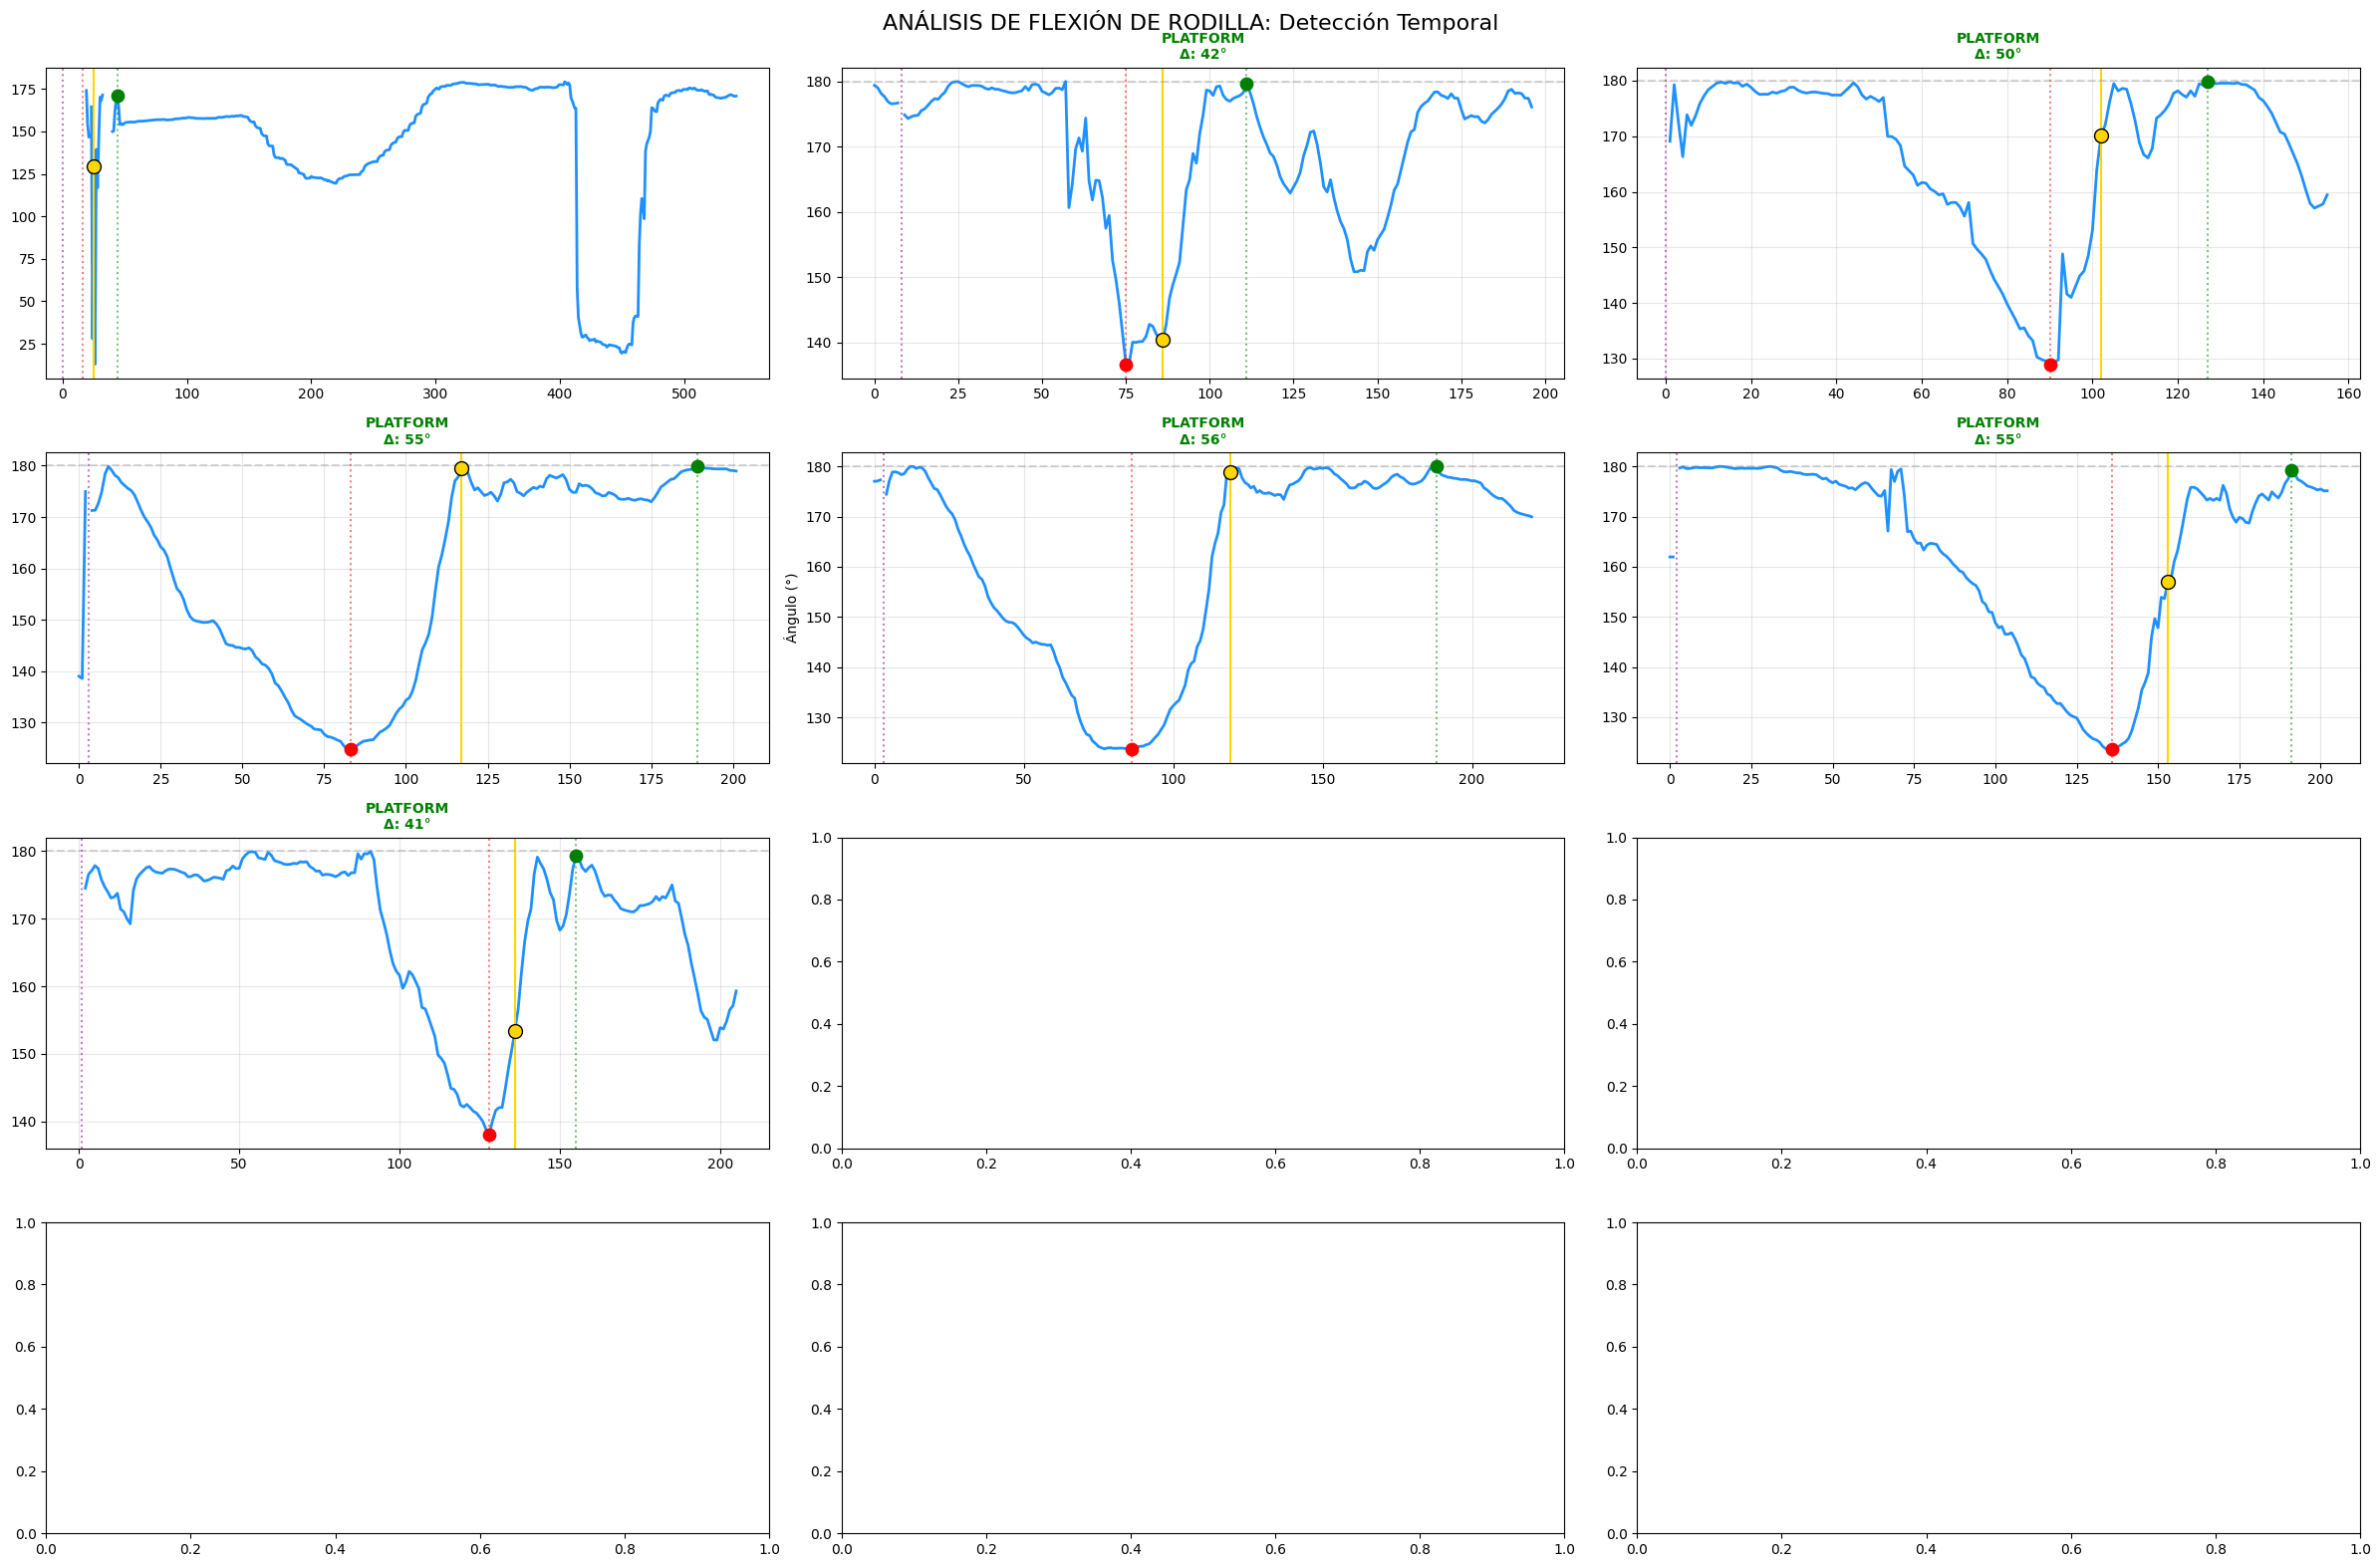

In [ ]:
# --- BUCLE 1: VALIDACIÓN DE FASES (RODILLA) ---

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(24, 16))
axes = axes.flatten() 

for idx, file_path in enumerate(archivos_malos):
    try:
        df = pd.read_csv(file_path)
        
        # 1. Calcular Ángulos
        angulos_izquierda = []
        for i in range(len(df)):
            l_hip = [df.loc[i, 'LEFT_HIP_x'], df.loc[i, 'LEFT_HIP_y']]
            l_knee = [df.loc[i, 'LEFT_KNEE_x'], df.loc[i, 'LEFT_KNEE_y']]
            l_ankle = [df.loc[i, 'LEFT_ANKLE_x'], df.loc[i, 'LEFT_ANKLE_y']]
            angulos_izquierda.append(calculate_angle(l_hip, l_knee, l_ankle))
        
        df['angulo'] = angulos_izquierda
        
        # 2. Detectar Fases
        start, min_f, max_f, target_f = detectar_fases_saque(df['angulo'])
        
        # Extraer valores para pintar
        start_val = df.loc[start, 'angulo']
        min_val = df.loc[min_f, 'angulo']
        max_val = df.loc[max_f, 'angulo']
        target_val = df.loc[target_f, 'angulo']
        
        # 3. Pintar Gráfica
        ax = axes[idx]
        
        tipo = "PINPOINT" if "pinpoint" in file_path.name.lower() else "PLATFORM"
        color_titulo = "blue" if tipo == "PINPOINT" else "green"
        
        # Línea de ángulo
        ax.plot(df['frame_id'], df['angulo'], color='dodgerblue', linewidth=2)
        
        # Puntos Clave
        ax.scatter(df.loc[start, 'frame_id'], start_val, color='purple', s=80, zorder=5, label='Inicio')
        ax.scatter(df.loc[min_f, 'frame_id'], min_val, color='red', s=80, zorder=5, label='Carga')
        ax.scatter(df.loc[target_f, 'frame_id'], target_val, color='gold', s=100, edgecolor='black', zorder=10, label='Target')
        ax.scatter(df.loc[max_f, 'frame_id'], max_val, color='green', s=80, zorder=5, label='Extensión')

        # Líneas Verticales
        ax.axvline(x=df.loc[start, 'frame_id'], color='purple', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[min_f, 'frame_id'], color='red', linestyle=':', alpha=0.5)
        ax.axvline(x=df.loc[target_f, 'frame_id'], color='gold', linestyle='-', linewidth=1.5)
        ax.axvline(x=df.loc[max_f, 'frame_id'], color='green', linestyle=':', alpha=0.5)
        
        # Título y Decoración
        subida = int(max_val - min_val)
        ax.set_title(f"{file_path.name}}°", fontsize=10, color=color_titulo, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=180, color='gray', linestyle='--', alpha=0.3)
        
        # Etiquetas solo en bordes
        if idx % 4 == 0: ax.set_ylabel("Ángulo (°)")
        if idx >= 12: ax.set_xlabel("Frame")
        
        # Leyenda solo en el primero
        if idx == 0: ax.legend(loc='lower right', fontsize=8)

    except Exception as e:
        print(f"⚠️ Error en {file_path.name}: {e}")

plt.suptitle("ANÁLISIS DE FLEXIÓN DE RODILLA: Detección Temporal", fontsize=16)
plt.tight_layout()
plt.show()

**Analizamos duplicados por si se hubiera colado uno**

In [45]:
duplicados = df.duplicated().sum()
if duplicados > 0:
    print(f"\nHay {duplicados} filas duplicadas.")
else:
    print("No hay filas duplicadas.")

No hay filas duplicadas.
